<a href="https://colab.research.google.com/github/aliabusohiban/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales
- Author: Ali Abu Sohiban

## Project Overview
## Load and Inspect Data


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')
fpath = '/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df_sales = pd.read_csv(fpath)
df_sales.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


In [19]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


We have 8523 rows and 12 columns.


*   7 categorical columns.
*   5 numerical columns.



## Clean Data

In [20]:
df_sales.duplicated().sum()

np.int64(0)

We don't have any duplicated values.

In [21]:
missing = df_sales.isna().sum()
missing

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


We see that we have missing values in tow columns:

*   1463 missng value in `Item_Weight`
*   2410 missing value in `Outlet_Size`



Here we find the data type for each variable:

In [22]:
df_sales.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [23]:
null_Item_W = df_sales['Item_Weight'].isnull()
df_sales[null_Item_W]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
18,DRI11,NaN,Low Fat,0.034238,Hard Drinks,113.2834,OUT027,1985,Medium,Tier 3,Supermarket Type3,2303.6680
21,FDW12,NaN,Regular,0.035400,Baking Goods,144.5444,OUT027,1985,Medium,Tier 3,Supermarket Type3,4064.0432
23,FDC37,NaN,Low Fat,0.057557,Baking Goods,107.6938,OUT019,1985,Small,Tier 1,Grocery Store,214.3876
29,FDC14,NaN,Regular,0.072222,Canned,43.6454,OUT019,1985,Small,Tier 1,Grocery Store,125.8362
...,...,...,...,...,...,...,...,...,...,...,...,...
8485,DRK37,NaN,Low Fat,0.043792,Soft Drinks,189.0530,OUT027,1985,Medium,Tier 3,Supermarket Type3,6261.8490
8487,DRG13,NaN,Low Fat,0.037006,Soft Drinks,164.7526,OUT027,1985,Medium,Tier 3,Supermarket Type3,4111.3150
8488,NCN14,NaN,Low Fat,0.091473,Others,184.6608,OUT027,1985,Medium,Tier 3,Supermarket Type3,2756.4120
8490,FDU44,NaN,Regular,0.102296,Fruits and Vegetables,162.3552,OUT019,1985,Small,Tier 1,Grocery Store,487.3656


In [24]:
mean_item = df_sales['Item_Weight'].mean()
df_sales['Item_Weight'] = df_sales['Item_Weight'].fillna(mean_item)
df_sales['Item_Weight'].isna().sum()

np.int64(0)

We have used the mean of the `Items_waight` as a placeholder.

In [25]:
df_sales['Outlet_Size'] = df_sales['Outlet_Size'].fillna('MISSING')
df_sales['Outlet_Size'].isna().sum()

np.int64(0)

In the `Outlet_Size` column we have used 'Missing' as a placeholder

In [26]:
df_sales['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


We see that there is 3 wrong values, we must replace it by a the original ones.

In [27]:
df_sales['Item_Fat_Content'] = df_sales['Item_Fat_Content'].replace('LF', 'Low Fat').replace('reg', 'Regular').replace('low fat', 'Low Fat')
df_sales['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


Below we show the counts for every categorical column, to check for inconsistencies in it.
> We found that there is no inconsistencies in the columns.


In [28]:
string_cols = df_sales.select_dtypes('object').columns
for col in string_cols:
  print(f"Value Counts for {col}")
  print(df_sales[col].value_counts())
  print('\n')

Value Counts for Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Value Counts for Item_Fat_Content
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


Value Counts for Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


Value Counts for Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    93

Below we have a summery statistics for every numerical column.

In [29]:
numeric_cols = df_sales.select_dtypes('number').columns
print("=== Statistical Summary ===")
print('\n')
for col in numeric_cols:
  print(f"{col}:")
  print(f'The mean: {df_sales[col].mean()}')
  print(f'The maximum: {df_sales[col].max()}')
  print(f'The minimum: {df_sales[col].min()}')
  print('\n')


=== Statistical Summary ===


Item_Weight:
The mean: 12.857645184135976
The maximum: 21.35
The minimum: 4.555


Item_Visibility:
The mean: 0.06613202877895108
The maximum: 0.328390948
The minimum: 0.0


Item_MRP:
The mean: 140.9927819781767
The maximum: 266.8884
The minimum: 31.29


Outlet_Establishment_Year:
The mean: 1997.8318667135984
The maximum: 2009
The minimum: 1985


Item_Outlet_Sales:
The mean: 2181.288913575032
The maximum: 13086.9648
The minimum: 33.29




This is the describe for the data after claening.

In [30]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Exploratory Data Analysis

In [31]:
df_sales.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300000,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920000,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500000,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200000,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,MISSING,Tier 3,Grocery Store,732.3800
4,NCD19,8.930000,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395000,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650000,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,12.857645,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200000,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,MISSING,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200000,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,MISSING,Tier 2,Supermarket Type1,4710.5350


In [32]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [33]:
df_sales['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


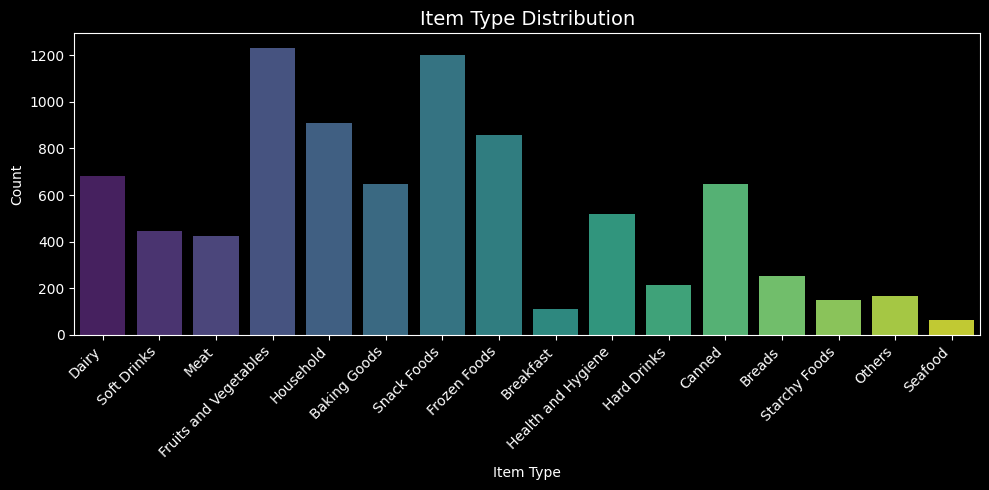

In [34]:
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(10,5))

sns.countplot(
    data=df_sales,
    x='Item_Type',
    palette='viridis',
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_title("Item Type Distribution", fontsize=14, color='white')
ax.set_xlabel("Item Type", color='white')
ax.set_ylabel("Count", color='white')

plt.tight_layout()

In [35]:
def cat_uni (x, order=None, rotation=None):
  plt.style.use('dark_background')
  fig, ax = plt.subplots()
  sns.countplot(
    data=df_sales,
    x=x,
    order=order,
    palette='viridis',
    ax=ax)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='right')
  ax.set_title(f'{x} Distribution', fontsize=14, color='white')
  ax.set_xlabel("Item Type", color='white')
  plt.tight_layout()

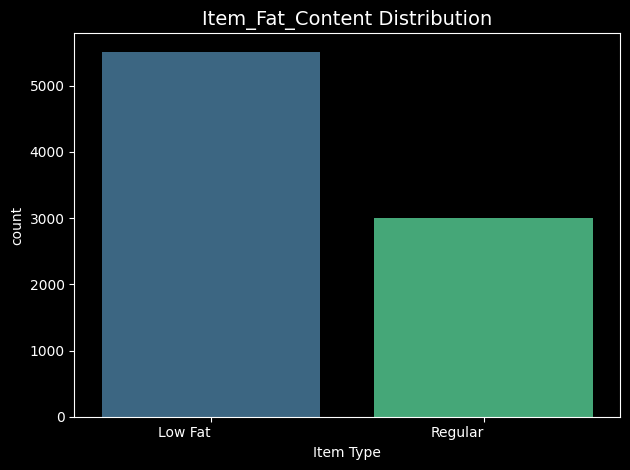

In [36]:
cat_uni('Item_Fat_Content')

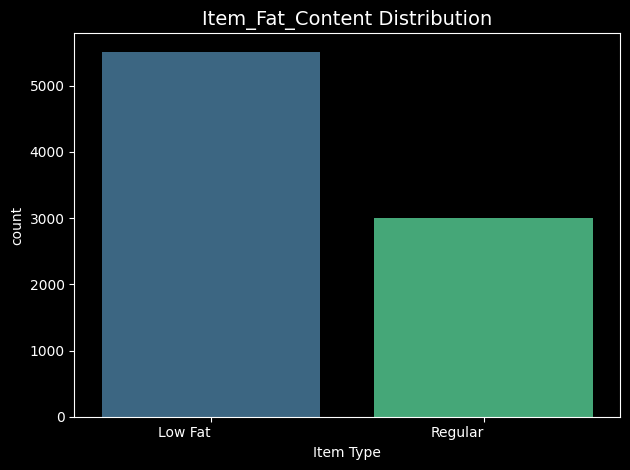

In [37]:
cat_uni('Item_Fat_Content');

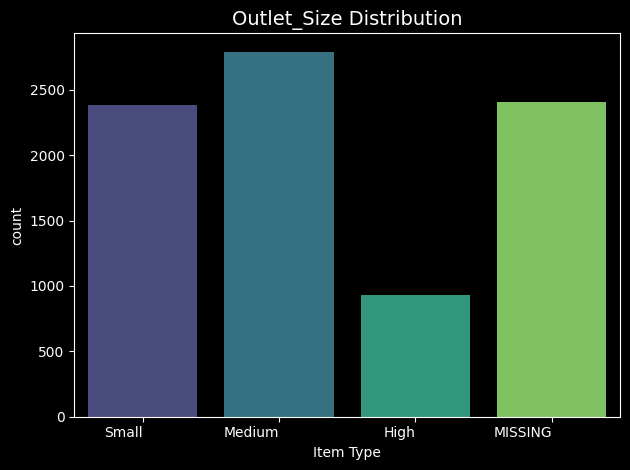

In [38]:
order_size = ['Small', 'Medium', 'High', 'MISSING']
cat_uni('Outlet_Size', order=order_size)

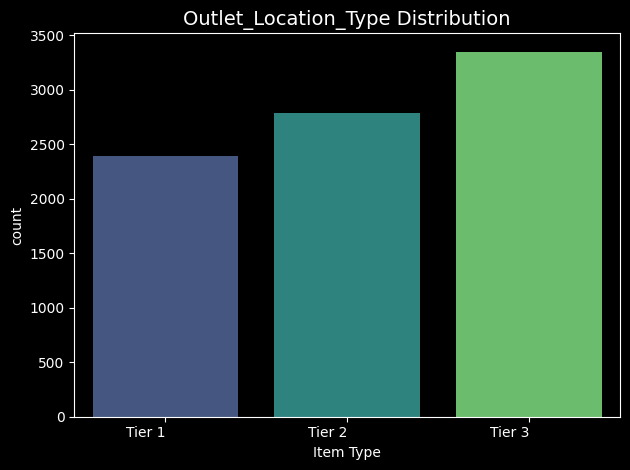

In [39]:
order_tier= ['Tier 1', 'Tier 2', 'Tier 3']
cat_uni('Outlet_Location_Type', order=order_tier)


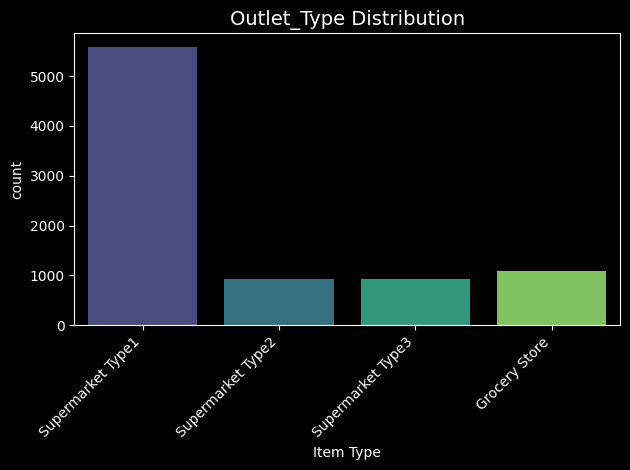

In [40]:
order_super = ['Supermarket Type1', 'Supermarket Type2', 'Supermarket Type3', 'Grocery Store']
cat_uni('Outlet_Type', order=order_super, rotation=45)


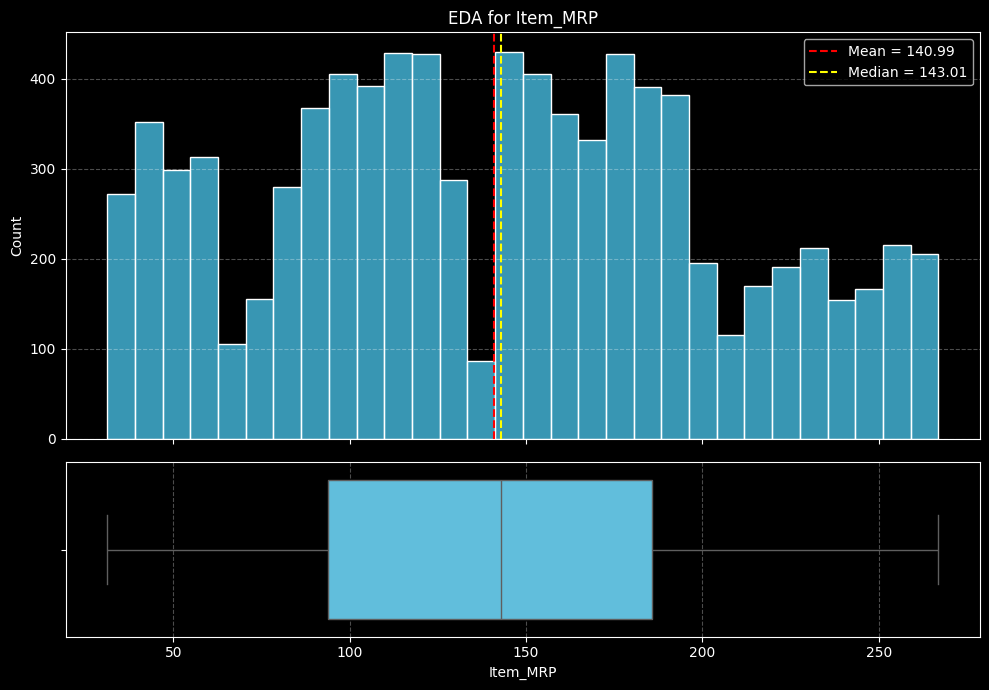

In [41]:
x = 'Item_MRP'
gridspec = {"height_ratios":[0.7,0.3]}

fig, axes = plt.subplots(nrows=2, figsize=(10,7), gridspec_kw=gridspec, sharex=True)

sns.histplot(
        data=df_sales,
        x=x,
        bins=30,
        color='#4cc9f0',
        edgecolor='white',
        ax=axes[0]
    )
mean_value = df_sales[x].mean()
med_value = df_sales[x].median()

axes[0].axvline(mean_value, color='red', ls='--',
                    label=f"Mean = {mean_value:,.2f}")
axes[0].axvline(med_value, color='yellow', ls='--',
                    label=f"Median = {med_value:,.2f}")

axes[0].legend()
sns.boxplot(
        data=df_sales,
        x=x,
        ax=axes[1],
        color='#4cc9f0'
    )
axes[0].set_title(f'EDA for {x}', color='white')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
def num_uni(x):
   gridspec = {"height_ratios":[0.7,0.3]}
   fig, axes = plt.subplots(nrows=2, figsize=(10,7), gridspec_kw=gridspec, sharex=True)
   sns.histplot(
        data=df_sales,
        x=x,
        bins=30,
        color='#4cc9f0',
        edgecolor='white',
        ax=axes[0])
   mean_value = df_sales[x].mean()
   med_value = df_sales[x].median()
   axes[0].axvline(mean_value, color='red', ls='--',
                    label=f"Mean = {mean_value:,.2f}")
   axes[0].axvline(med_value, color='yellow', ls='--',
                    label=f"Median = {med_value:,.2f}")
   axes[0].legend()
   sns.boxplot(
        data=df_sales,
        x=x,
        ax=axes[1],
        color='#4cc9f0')
   axes[0].set_title(f'EDA for {x}', color='white')
   axes[0].grid(axis='y', linestyle='--', alpha=0.3)
   axes[1].grid(axis='x', linestyle='--', alpha=0.3)
   plt.tight_layout()

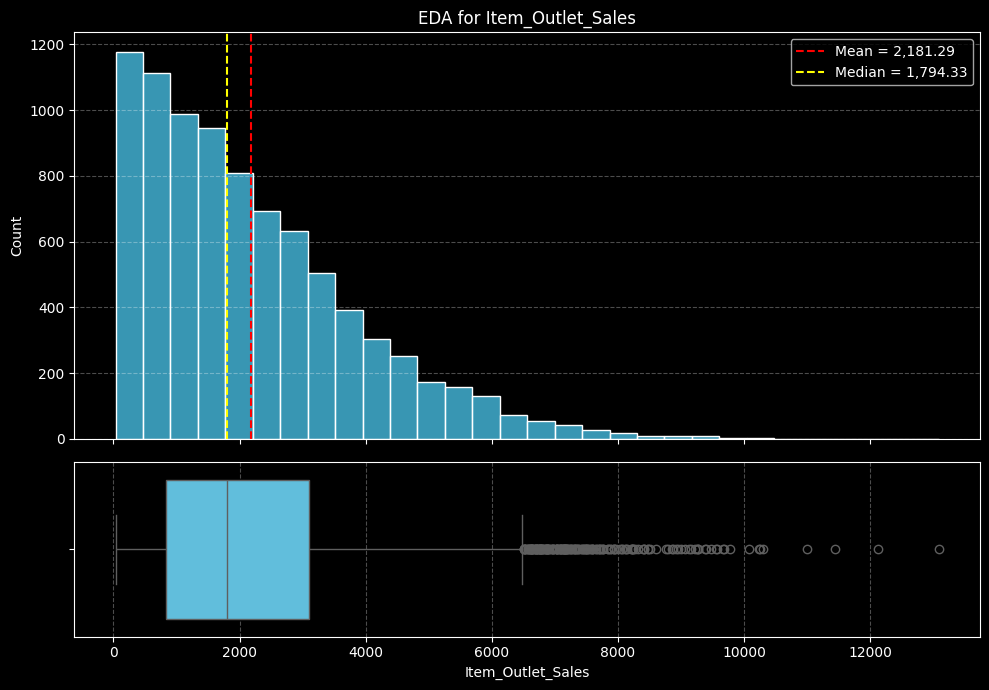

In [43]:
num_uni('Item_Outlet_Sales')

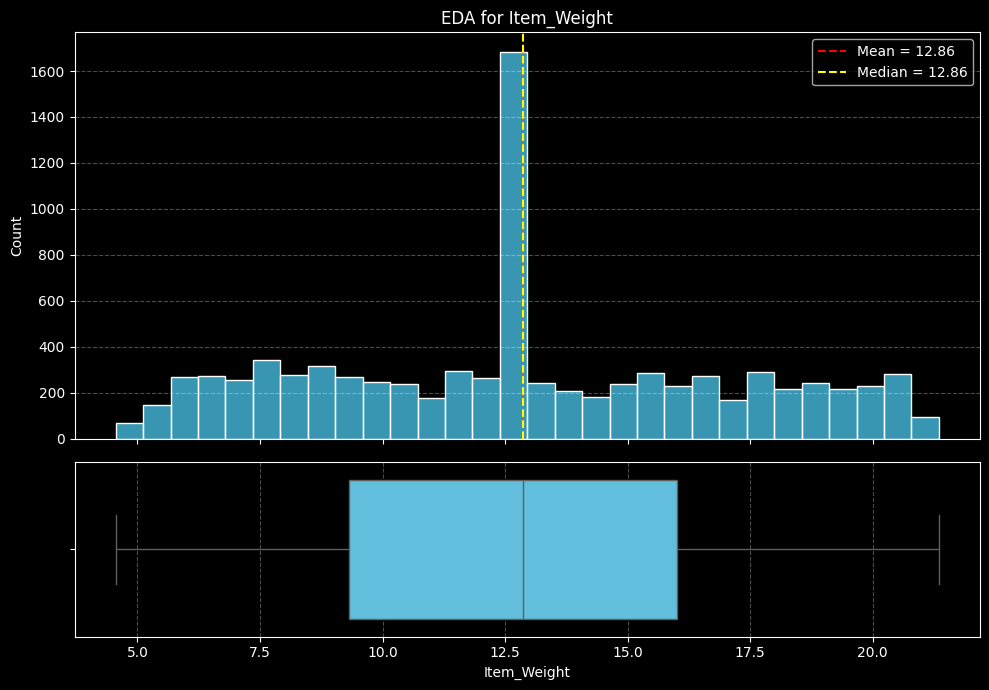

In [44]:
num_uni('Item_Weight')

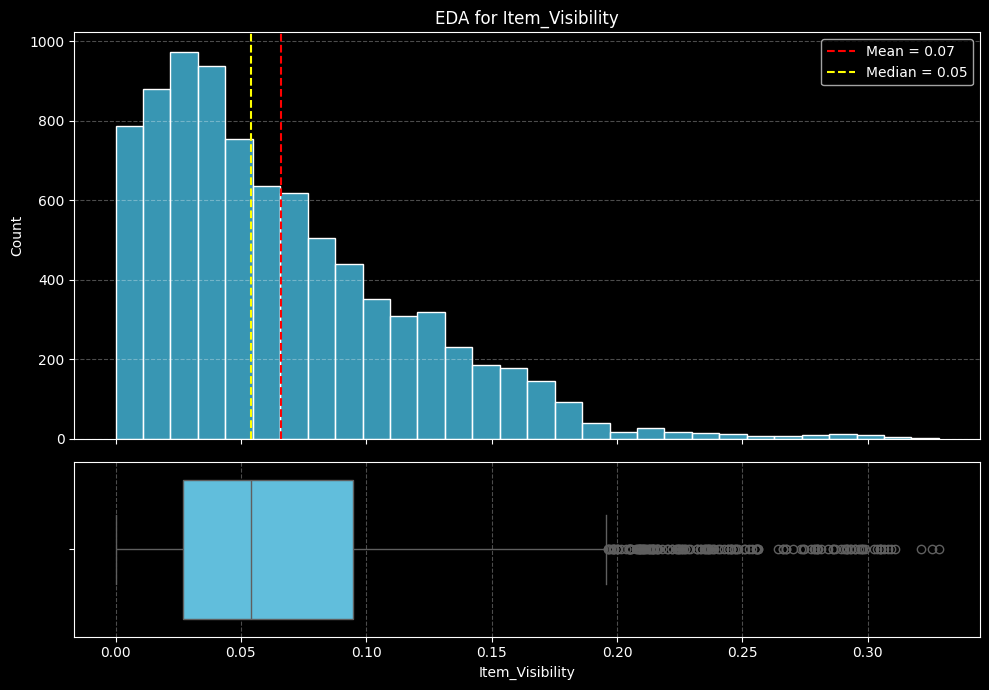

In [45]:
num_uni('Item_Visibility')

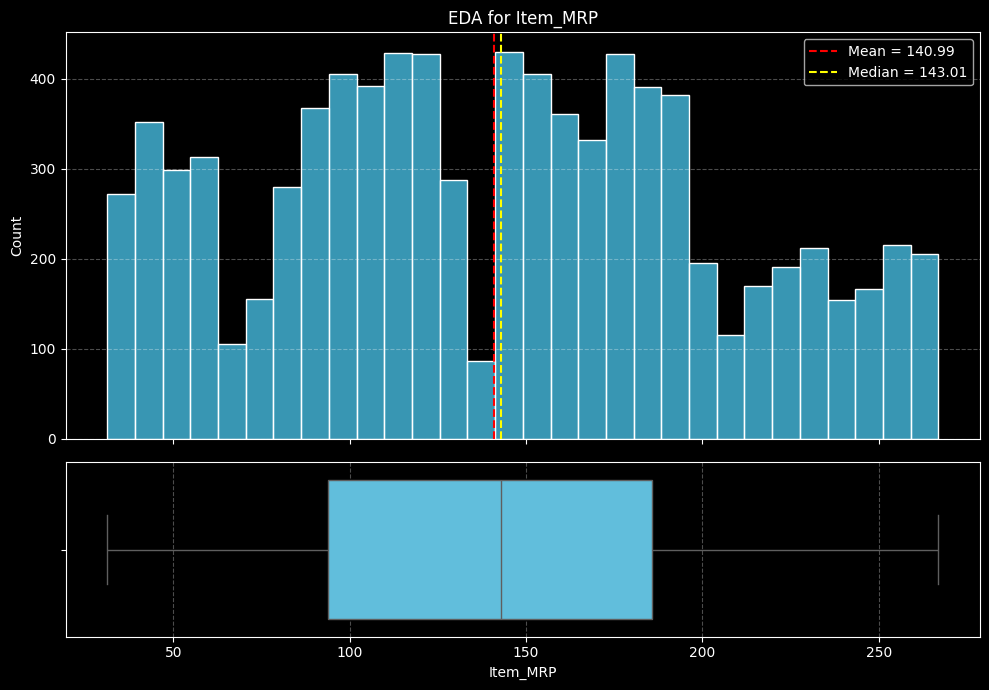

In [46]:
num_uni('Item_MRP')

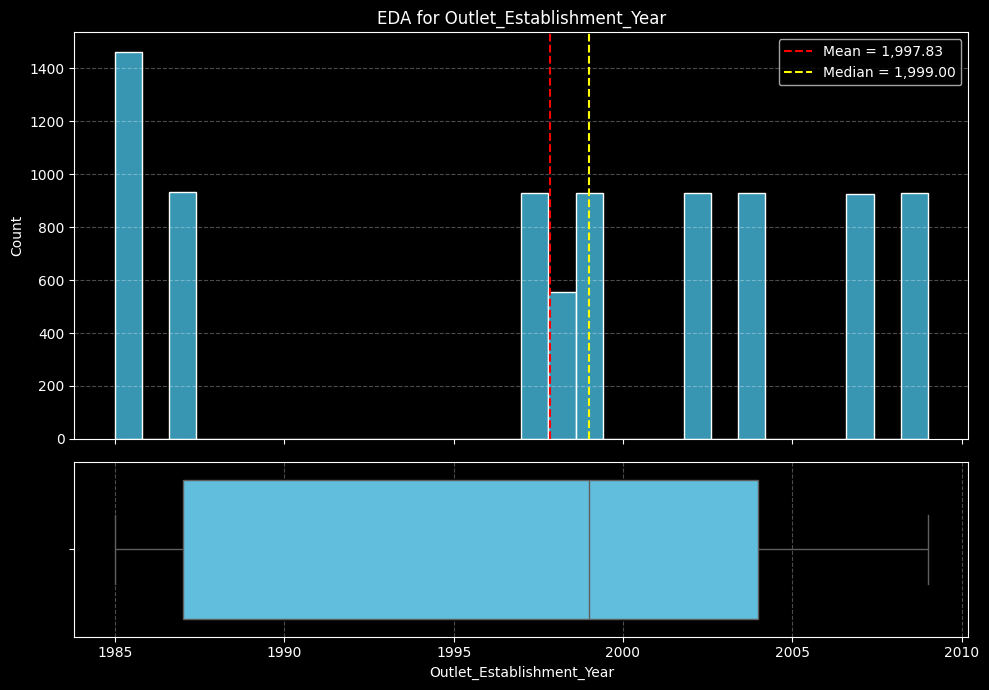

In [47]:
num_uni('Outlet_Establishment_Year')

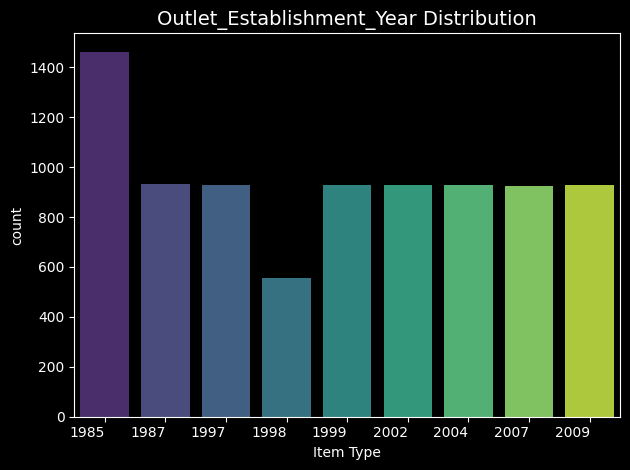

In [48]:
cat_uni('Outlet_Establishment_Year')

In [49]:
def plot_numeric(x):
  fig, axes = plt.subplots(nrows=2, figsize=(10,5), sharex=True)
  sns.histplot(data=df_sales,x=x, ax = axes[0], color='#4cc9f0')
  mean_value = df_sales[x].mean()
  axes[0].axvline(mean_value,color='red', ls='--', label=f"Mean Value = ${mean_value:,.2f}",);
  med_value = df_sales[col].median()
  axes[0].axvline(med_value,color='black', ls='--', label=f"Median Value = ${med_value:,.2f}");
  sns.boxplot(data=df_sales, x = x, ax = axes[1],  color='#4cc9f0')
  axes[0].set_title(f'EDA for {x}')
  plt.tight_layout()
  plt.show()

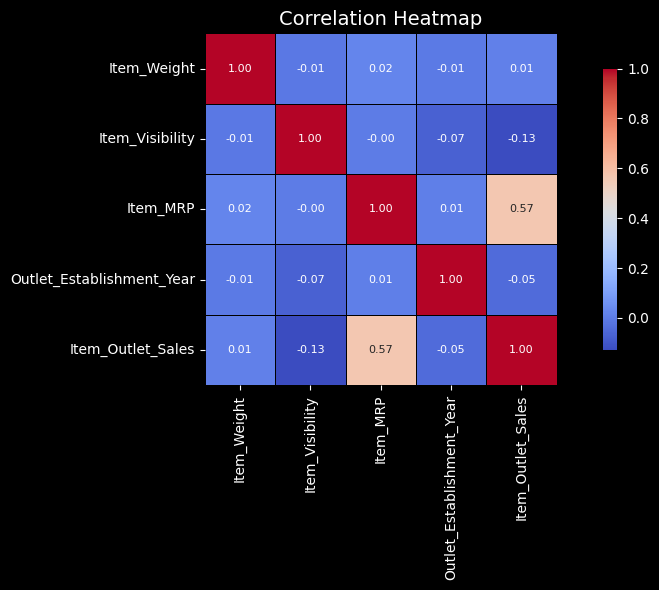

In [57]:
plt.style.use('dark_background')

corr = df_sales.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',              # cleaner numbers
    linewidths=0.5,         # separates cells
    linecolor='black',
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={"size":8},
    ax=ax
)

ax.set_title('Correlation Heatmap', fontsize=14, color='white')

plt.tight_layout()
plt.show()

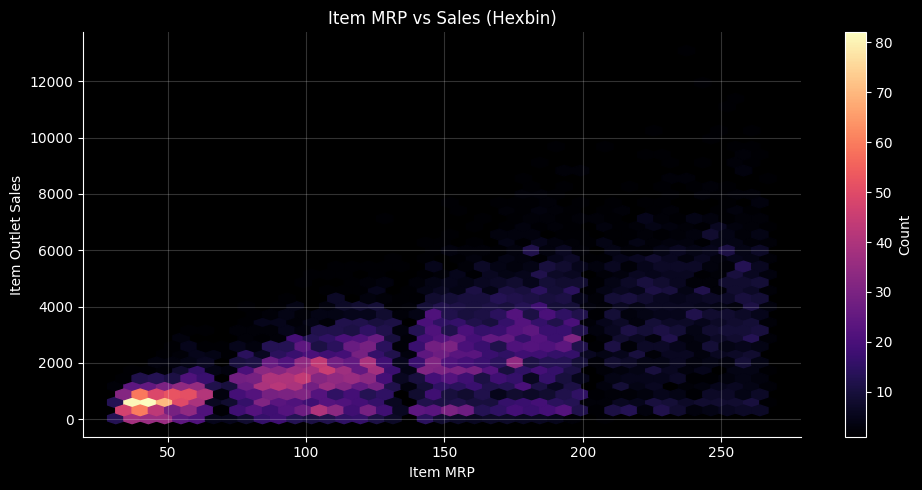

In [51]:
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(10,5))

hb = ax.hexbin(
    df_sales['Item_MRP'],
    df_sales['Item_Outlet_Sales'],
    gridsize=40,          # controls resolution
    cmap='magma',
    mincnt=1
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Count')

ax.set_title('Item MRP vs Sales (Hexbin)', color='white')
ax.set_xlabel('Item MRP', color='white')
ax.set_ylabel('Item Outlet Sales', color='white')

ax.grid(alpha=0.2)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## Feature Inspection